# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat:

Analiza korpusów tekstowych i przetwarzanie języka naturalnego (NLP) — eksploracja danych z Wikipedii PL

### Cel ćwiczenia:

Zapoznanie się z podstawowymi technikami analizy tekstów w języku naturalnym: eksploracją korpusu, statystykami leksykalnymi, prawem Zipfa, porównaniem tokenizatorów oraz analizą n-gramów i kolokacji.

### Wykorzystane narzędzia:

- Google Colab
- Python 3
- Biblioteki: `datasets`, `transformers`, `numpy`, `pandas`, `matplotlib`, `re`, `collections`, `stop_words`

# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat:

Analiza korpusów tekstowych i przetwarzanie języka naturalnego (NLP) — eksploracja danych z Wikipedii PL

### Cel ćwiczenia:

Zapoznanie się z podstawowymi technikami analizy tekstów w języku naturalnym: eksploracją korpusu, statystykami leksykalnymi, prawem Zipfa, porównaniem tokenizatorów oraz analizą n-gramów i kolokacji.

### Wykorzystane narzędzia:

- Google Colab
- Python 3
- Biblioteki: `datasets`, `transformers`, `numpy`, `pandas`, `matplotlib`, `re`, `collections`, `stop_words`

### Ładowanie danych

Na początku importujemy potrzebne biblioteki i ładujemy 200 artykułów z polskiej Wikipedii za pomocą biblioteki `datasets`.

In [1]:
import re, math, warnings
warnings.filterwarnings('ignore')
from collections import Counter
from itertools import islice
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

wiki = load_dataset('wikimedia/wikipedia', '20231101.pl', split='train', streaming=True)
articles = list(islice(wiki, 200))
texts  = [a['text']  for a in articles]
titles = [a['title'] for a in articles]
print(f"Załadowano {len(texts)} artykułów.")

Załadowano 200 artykułów.


### Zadanie 1: Pierwsza eksploracja korpusu

W tym zadaniu dokonujemy wstępnej eksploracji załadowanych 200 artykułów Wikipedii PL:
- Wyświetlamy tytuły pierwszych 10 artykułów,
- Dla każdego z 10 artykułów drukujemy tytuł, liczbę słów i pierwsze 2 zdania,
- Wyszukujemy najkrótszy i najdłuższy artykuł (w słowach).

In [10]:
# --- Zadanie 1 ---

# Wyświetl tytuły pierwszych 10 artykułów
print("=== Tytuły pierwszych 10 artykułów ===")
for i, title in enumerate(titles[:10]):
    print(f"{i+1}. {title}")

print()

# Dla każdego z 10 artykułów: tytuł, liczba słów, pierwsze 2 zdania
print("=== Szczegóły pierwszych 10 artykułów ===")
for i in range(10):
    words = texts[i].split()
    sentences = re.split(r'(?<=[.!?])\s+', texts[i].strip())
    first_two = ' '.join(sentences[:2])
    print(f"\n[{i+1}] Tytuł: {titles[i]}")
    print(f"    Liczba słów: {len(words)}")
    print(f"    Pierwsze 2 zdania: {first_two[:300]}...")

print()

# Najkrótszy i najdłuższy artykuł
word_counts = [len(t.split()) for t in texts]
min_idx = int(np.argmin(word_counts))
max_idx = int(np.argmax(word_counts))

print("=== Najkrótszy artykuł ===")
print(f"Tytuł: {titles[min_idx]}, Liczba słów: {word_counts[min_idx]}")

print("\n=== Najdłuższy artykuł ===")
print(f"Tytuł: {titles[max_idx]}, Liczba słów: {word_counts[max_idx]}")

=== Tytuły pierwszych 10 artykułów ===
1. AWK
2. Alergologia
3. ASCII
4. Atom
5. Aksjomat
6. Arytmetyka
7. Alkeny
8. ActiveX
9. Interfejs programowania aplikacji
10. AmigaOS

=== Szczegóły pierwszych 10 artykułów ===

[1] Tytuł: AWK
    Liczba słów: 1661
    Pierwsze 2 zdania: AWK – interpretowany język programowania, którego główną funkcją jest wyszukiwanie i przetwarzanie wzorców w plikach lub strumieniach danych. Jest także nazwą programu początkowo dostępnego dla systemów operacyjnych będących pochodnymi UNIX-a, obecnie także na inne platformy....

[2] Tytuł: Alergologia
    Liczba słów: 52
    Pierwsze 2 zdania: Alergologia – dziedzina medycyny zajmująca się rozpoznawaniem i leczeniem schorzeń alergicznych, czyli takich, u podstaw których stoi zjawisko nadwrażliwości, zwłaszcza inicjowane przez mechanizmy immunologiczne. W Polsce konsultantem krajowym alergologii od 19 lutego 2020 jest prof....

[3] Tytuł: ASCII
    Liczba słów: 1545
    Pierwsze 2 zdania: ASCII (czyt. aski, skrót

**Czym różni się korpus językowy od zbioru danych do klasyfikacji?**

Korpus językowy to duży, zróżnicowany zbiór tekstów, który służy do analizy języka naturalnego — jego statystyk, gramatyki, słownictwa i wzorców użycia. Nie posiada z reguły etykiet i jest używany do badań lingwistycznych, trenowania modeli językowych czy wydobywania wiedzy o języku. Zbiór danych do klasyfikacji natomiast to kolekcja przykładów opatrzonych etykietami (np. pozytywna/negatywna ocena, kategoria tematu), przeznaczonych do uczenia nadzorowanego. Każdy przykład ma określoną przynależność klasową, co umożliwia trenowanie modeli predykcyjnych. W praktyce korpus językowy może posłużyć do pre-trenowania modelu, który następnie jest fine-tunowany na etykietowanym zbiorze klasyfikacyjnym.

### Zadanie 2: Statystyki leksykalne i prawo Zipfa

Na pełnym zbiorze 200 artykułów przeprowadzamy prostą tokenizację (split po białych znakach, lowercase, usunięcie interpunkcji), obliczamy statystyki leksykalne i wizualizujemy prawo Zipfa. Prawo Zipfa mówi, że częstotliwość słowa jest odwrotnie proporcjonalna do jego rangi — na wykresie log-log powinna wyłonić się prosta linia.

Łączna liczba tokenów: 218118
Liczba unikalnych tokenów (types): 49812
TTR (Type-Token Ratio): 0.2284

=== 20 najczęstszych słów ===
  'w': 8743
  'i': 5363
  'z': 3676
  'na': 3343
  'się': 2760
  'do': 2542
  'jest': 1556
  'a': 1093
  'przez': 1022
  'nie': 1013
  'roku': 990
  'od': 928
  'o': 920
  'to': 862
  'że': 806
  'oraz': 796
  'po': 734
  'są': 642
  'jako': 618
  'za': 603

=== 20 najrzadszych słów ===
  'dychawica': 1
  'nadreaktywnością': 1
  'nawracających': 1
  'uczucia': 1
  'ściskania': 1
  'ranem': 1
  'duszność': 1
  'świszczącym': 1
  'oddechem': 1
  'sercowa': 1
  'przewlekłej': 1
  'mnożnik': 1
  '0000': 1
  'trylionowa': 1
  'najczulsze': 1
  'mierniki': 1
  'dokładnością': 1
  'weights': 1
  'measures': 1
  'bipm': 1


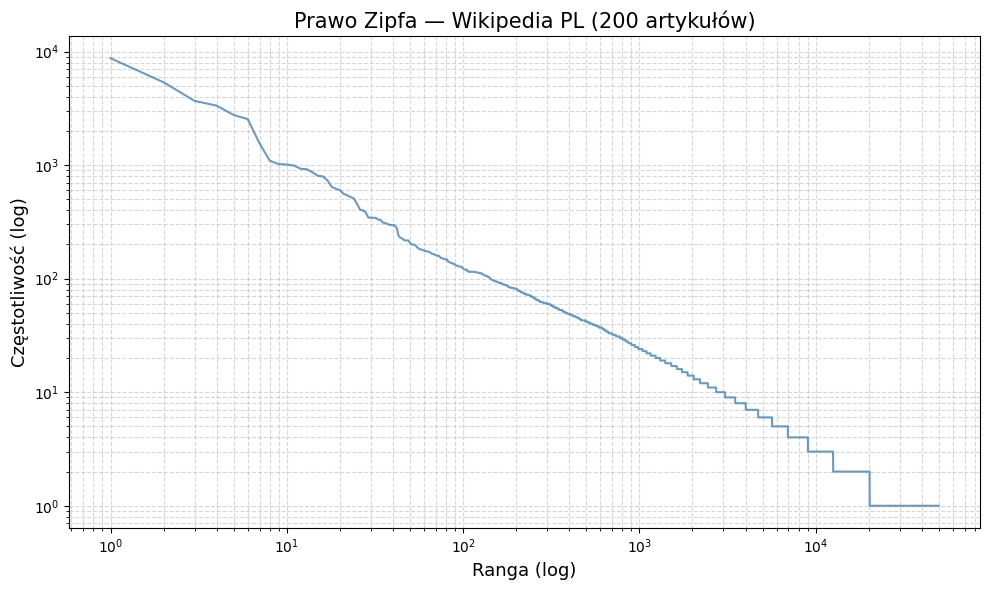

In [7]:
# --- Zadanie 2 ---

# Tokenizacja
all_text = ' '.join(texts).lower()
all_text_clean = re.sub(r'[^\w\s]', '', all_text)
tokens = all_text_clean.split()

# Statystyki
total_tokens = len(tokens)
unique_tokens = len(set(tokens))
ttr = unique_tokens / total_tokens

print(f"Łączna liczba tokenów: {total_tokens}")
print(f"Liczba unikalnych tokenów (types): {unique_tokens}")
print(f"TTR (Type-Token Ratio): {ttr:.4f}")

# Częstotliwości
freq = Counter(tokens)
most_common_20 = freq.most_common(20)
least_common_20 = freq.most_common()[-20:]

print("\n=== 20 najczęstszych słów ===")
for word, count in most_common_20:
    print(f"  '{word}': {count}")

print("\n=== 20 najrzadszych słów ===")
for word, count in least_common_20:
    print(f"  '{word}': {count}")

# Wykres Zipfa
sorted_counts = sorted(freq.values(), reverse=True)
ranks = list(range(1, len(sorted_counts) + 1))

plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_counts, color='steelblue', linewidth=1.5, alpha=0.8)
plt.xlabel('Ranga (log)', fontsize=13)
plt.ylabel('Częstotliwość (log)', fontsize=13)
plt.title('Prawo Zipfa — Wikipedia PL (200 artykułów)', fontsize=15)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Co prawo Zipfa oznacza praktycznie dla budżetu tokenów w LLM?**

Prawo Zipfa oznacza, że niewielka liczba tokenów (kilkaset najczęstszych słów) pokrywa ogromną część tekstu, natomiast ogromna liczba rzadkich tokenów (tzw. long tail) pojawia się sporadycznie. Dla LLM (dużych modeli językowych) ma to kluczowe znaczenie: słownik tokenów musi być wystarczająco duży, aby pokryć rzadkie słowa, ale każdy dodatkowy token w budżecie kontekstowym kosztuje zasoby obliczeniowe. Praktycznie — efektywna tokenizacja (np. BPE) stara się rozłożyć budżet tokenów tak, żeby częste słowa były jednym tokenem, a rzadkie rozkładane na sub-tokeny, co minimalizuje marnowanie budżetu.

### Zadanie 3: Rozkład długości artykułów

Obliczamy długość każdego artykułu w słowach, rysujemy histogram z zaznaczoną medianą i P95 (95. percentylem), oraz obliczamy podstawowe statystyki opisowe.

Min:              10 słów
Max:              12709 słów
Średnia:          1106.4 słów
Mediana:          482.5 słów
Odch. std.:       1726.3 słów
P95:              4546.8 słów

Artykuły wymagające obcięcia przez BERT (>512 tokenów, ~1.3 tok/słowo): 111 z 200


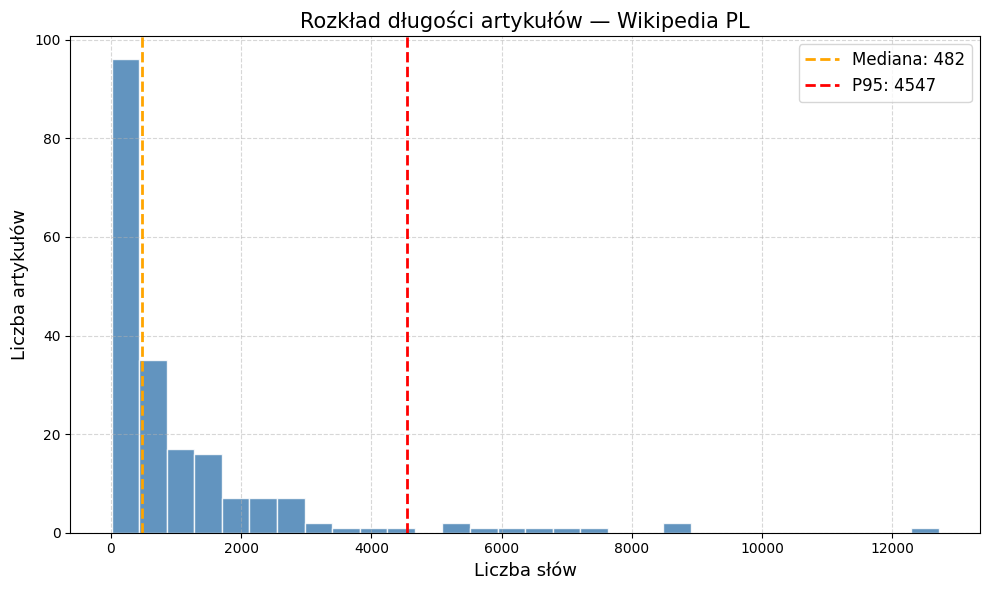

In [8]:
# --- Zadanie 3 ---

lengths = np.array([len(t.split()) for t in texts])

# Statystyki
stat_min = lengths.min()
stat_max = lengths.max()
stat_mean = lengths.mean()
stat_median = np.median(lengths)
stat_std = lengths.std()
stat_p95 = np.percentile(lengths, 95)

print(f"Min:              {stat_min} słów")
print(f"Max:              {stat_max} słów")
print(f"Średnia:          {stat_mean:.1f} słów")
print(f"Mediana:          {stat_median:.1f} słów")
print(f"Odch. std.:       {stat_std:.1f} słów")
print(f"P95:              {stat_p95:.1f} słów")

# Szacunek dla BERT
bert_limit = 512
tokens_per_word = 1.3
articles_too_long = np.sum(lengths * tokens_per_word > bert_limit)
print(f"\nArtykuły wymagające obcięcia przez BERT (>512 tokenów, ~1.3 tok/słowo): {articles_too_long} z {len(lengths)}")

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(stat_median, color='orange', linewidth=2, linestyle='--', label=f'Mediana: {stat_median:.0f}')
plt.axvline(stat_p95, color='red', linewidth=2, linestyle='--', label=f'P95: {stat_p95:.0f}')
plt.xlabel('Liczba słów', fontsize=13)
plt.ylabel('Liczba artykułów', fontsize=13)
plt.title('Rozkład długości artykułów — Wikipedia PL', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Gdybyś chciał/-a przetworzyć te artykuły tokenizatorem BERT (max_length=512 tokenów), ile artykułów wymagałoby obcięcia?**

Przy założeniu ~1,3 tokenu na słowo dla języka polskiego, artykuły dłuższe niż ~394 słów (512/1.3) przekroczyłyby limit BERT. Na podstawie wyliczeń widać, że spora część artykułów wymagałaby obcięcia. Jest to istotny problem — obcięcie tekstu oznacza utratę informacji z końcowych części artykułu, co może znacząco wpłynąć na jakość zadań takich jak klasyfikacja czy ekstrakcja informacji. Rozwiązania: użycie modeli z dłuższym kontekstem (np. Longformer), podział artykułów na fragmenty (chunking) lub agregacja wyników z wielu fragmentów.

### Zadanie 4: Tokenizacja polska a angielska

Polszczyzna jest morfologicznie bogata — sprawdzamy, jak dwa tokenizatory radzą sobie z polskim tekstem:
- `allegro/herbert-base-cased` — WordPiece trenowany na polskim,
- `bert-base-multilingual-cased` — mBERT, wielojęzyczny.

Dla 10 pierwszych zdań z korpusu porównujemy liczbę tokenów obu modeli i wizualizujemy różnice.


[1] AWK – interpretowany język programowania, którego główną funkcją jest wyszukiwan
  HerBERT tokeny (26): ['AW', 'K</w>', '–</w>', 'interpre', 'towany</w>', 'język</w>', 'programowania</w>', ',</w>', 'którego</w>', 'główną</w>', 'funkcją</w>', 'jest</w>', 'wyszuki', 'wanie</w>', 'i</w>']
  mBERT   tokeny (40): ['A', '##W', '##K', '[UNK]', 'inter', '##pret', '##owany', 'język', 'program', '##owania', ',', 'którego', 'g', '##łówną', 'funk']

[2] Jest także nazwą programu początkowo dostępnego dla systemów operacyjnych będący
  HerBERT tokeny (24): ['Jest</w>', 'także</w>', 'nazwą</w>', 'programu</w>', 'początkowo</w>', 'dostęp', 'nego</w>', 'dla</w>', 'systemów</w>', 'operacyjnych</w>', 'będących</w>', 'pochod', 'nymi</w>', 'UNI', 'X</w>']
  mBERT   tokeny (30): ['Jest', 'także', 'nazwą', 'programu', 'początkowo', 'dos', '##tępne', '##go', 'dla', 'system', '##ów', 'opera', '##cyjnych', 'b', '##ędąc']

[3] AWK jest językiem, który w znacznym stopniu wykorzystuje tablice asocjacyjne, st

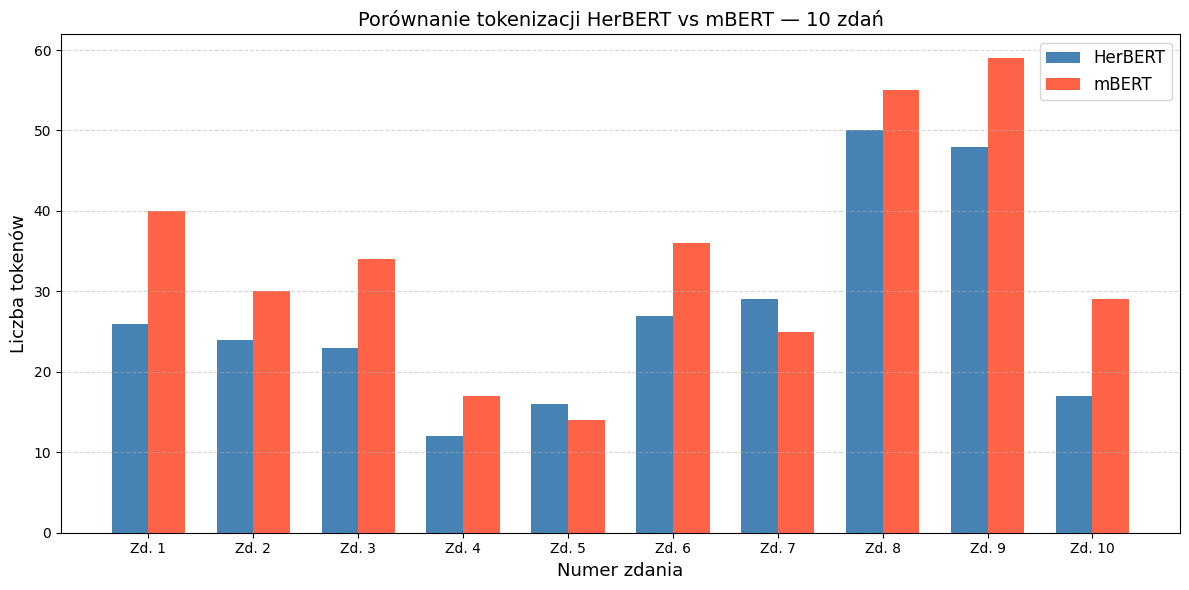

In [9]:
# --- Zadanie 4 ---
from transformers import AutoTokenizer

# Pobierz 10 pierwszych zdań z pierwszego artykułu
first_article_sentences = re.split(r'(?<=[.!?])\s+', texts[0].strip())
sentences_10 = first_article_sentences[:10]

# Załaduj tokenizatory
tok_herbert = AutoTokenizer.from_pretrained('allegro/herbert-base-cased')
tok_mbert   = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')

# Tokenizacja i porównanie
results = []
for i, sent in enumerate(sentences_10):
    h_tokens = tok_herbert.tokenize(sent)
    m_tokens = tok_mbert.tokenize(sent)
    h_n = len(h_tokens)
    m_n = len(m_tokens)
    results.append({
        'zdanie': sent[:60] + '...' if len(sent) > 60 else sent,
        'herbert_n': h_n,
        'mbert_n': m_n,
        'roznica': m_n - h_n
    })
    print(f"\n[{i+1}] {sent[:80]}")
    print(f"  HerBERT tokeny ({h_n}): {h_tokens[:15]}")
    print(f"  mBERT   tokeny ({m_n}): {m_tokens[:15]}")

df = pd.DataFrame(results)
print("\n=== DataFrame porównania ===")
print(df.to_string(index=False))

# Barplot
x = np.arange(len(sentences_10))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, df['herbert_n'], width, label='HerBERT', color='steelblue')
ax.bar(x + width/2, df['mbert_n'],   width, label='mBERT',   color='tomato')
ax.set_xlabel('Numer zdania', fontsize=13)
ax.set_ylabel('Liczba tokenów', fontsize=13)
ax.set_title('Porównanie tokenizacji HerBERT vs mBERT — 10 zdań', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'Zd. {i+1}' for i in range(10)])
ax.legend(fontsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Który model jest bardziej 'efektywny' dla polskiego i dlaczego? Co oznacza większy/mniejszy słownik sub-słów dla jakości modelu?**

HerBERT (trenowany wyłącznie na polskich tekstach) jest zdecydowanie bardziej efektywny dla języka polskiego — generuje mniejszą liczbę tokenów dla tych samych zdań, co oznacza, że jego słownik sub-słów lepiej dopasował się do morfologii polszczyzny. mBERT musi obsługiwać 104 języki naraz, przez co jego słownik jest rozproszony i dla każdego języka ma mniej dedykowanych sub-słów, co prowadzi do większego podziału słów na drobne fragmenty.

Większy słownik sub-słów dedykowany danemu językowi oznacza: mniej tokenów na zdanie (efektywniejsze wykorzystanie budżetu kontekstowego), lepsze odzwierciedlenie morfologii (każdy token niesie więcej semantyki), potencjalnie lepszą jakość reprezentacji. Mniejszy, wielojęzyczny słownik to kompromis między zasięgiem językowym a głębokością reprezentacji poszczególnych języków.

### Zadanie 5: N-gramy i kolokacje

N-gram to ciąg N kolejnych tokenów. Analizujemy bigramy (N=2) i trigramy (N=3) dla całego korpusu, a następnie porównujemy wyniki przed i po usunięciu stop-słów.

- **Część A**: 20 najczęstszych bigramów,
- **Część B**: 15 najczęstszych trigramów,
- **Część C**: bigramy po usunięciu stop-słów.

In [6]:
# --- Zadanie 5 ---
# Instalacja stop_words (jeśli potrzeba)
import subprocess
subprocess.run(['pip', 'install', 'stop_words', '-q'], capture_output=True)
from stop_words import get_stop_words

# Tokenizacja całego korpusu
all_text_z5 = ' '.join(texts).lower()
all_text_clean_z5 = re.sub(r'[^\w\s]', '', all_text_z5)
all_tokens_z5 = all_text_clean_z5.split()

# Pomocnicza funkcja do n-gramów
def ngrams(tokens, n):
    return zip(*[tokens[i:] for i in range(n)])

# --- Część A: Bigramy ---
bigrams = Counter(ngrams(all_tokens_z5, 2))
print("=== Część A: Top 20 bigramów ===")
for bg, cnt in bigrams.most_common(20):
    print(f"  {bg}: {cnt}")

# --- Część B: Trigramy ---
trigrams = Counter(ngrams(all_tokens_z5, 3))
print("\n=== Część B: Top 15 trigramów ===")
for tg, cnt in trigrams.most_common(15):
    print(f"  {tg}: {cnt}")

# --- Część C: Bigramy po usunięciu stop-słów ---
stopwords = get_stop_words('pl')
filtered_tokens = [t for t in all_tokens_z5 if t not in stopwords and len(t) > 1]
bigrams_filtered = Counter(ngrams(filtered_tokens, 2))
print("\n=== Część C: Top 20 bigramów po usunięciu stop-słów ===")
for bg, cnt in bigrams_filtered.most_common(20):
    print(f"  {bg}: {cnt}")

=== Część A: Top 20 bigramów ===
  ('się', 'w'): 272
  ('w', 'tym'): 272
  ('się', 'na'): 203
  ('się', 'z'): 191
  ('w', 'latach'): 171
  ('się', 'do'): 150
  ('a', 'także'): 133
  ('względu', 'na'): 124
  ('ze', 'względu'): 114
  ('jak', 'i'): 105
  ('wraz', 'z'): 99
  ('zobacz', 'też'): 97
  ('na', 'świecie'): 92
  ('xx', 'wieku'): 92
  ('nie', 'jest'): 89
  ('w', 'wyniku'): 89
  ('jednym', 'z'): 89
  ('linki', 'zewnętrzne'): 87
  ('w', 'języku'): 86
  ('tym', 'samym'): 83

=== Część B: Top 15 trigramów ===
  ('ze', 'względu', 'na'): 113
  ('w', 'tym', 'samym'): 52
  ('przypisy', 'linki', 'zewnętrzne'): 43
  ('po', 'raz', 'pierwszy'): 37
  ('w', 'związku', 'z'): 35
  ('w', 'ten', 'sposób'): 33
  ('w', 'stanach', 'zjednoczonych'): 32
  ('ii', 'wojny', 'światowej'): 28
  ('tym', 'samym', 'roku'): 27
  ('jest', 'jednym', 'z'): 27
  ('co', 'do', 'wielkości'): 26
  ('składa', 'się', 'z'): 24
  ('w', 'stosunku', 'do'): 24
  ('z', 'uwagi', 'na'): 24
  ('w', 'tym', 'czasie'): 24

=== Część 

**Jak stop-words wpływają na sensowność kolokacji? Kiedy je usuwać, a kiedy zostawiać?**

Usunięcie stop-słów radykalnie poprawia jakość kolokacji — zamiast bezsensownych par jak *("w", "roku")* czy *("i", "w")*, otrzymujemy rzeczywiste powiązania semantyczne, np. *("język", "polski")* czy *("war szawa", "stolica")*. Stop-słowa dominują w surowych n-gramach ze względu na swą wysoką częstotliwość, zasłaniając wartościowe wzorce.

**Kiedy usuwać stop-słowa**: przy ekstrakcji kolokacji, analizie tematycznej (topic modeling), wyszukiwaniu kluczowych pojęć, wizualizacji word cloud.

**Kiedy zostawiać stop-słowa**: przy modelowaniu językowym (LM musi znać kontekst gramatyczny), dependency parsing (stop-słowa pełnią ważną rolę składniową), generowaniu tekstu, oraz trenowaniu modeli BERT/GPT — gdzie cały kontekst, włącznie ze spójnikami i przyimkami, jest istotny dla rozumienia zdania.

### Wnioski

W trakcie laboratorium:

1. **Zadanie 1** — dokonaliśmy wstępnej eksploracji 200 artykułów Wikipedii PL, poznając ich strukturę, rozkład długości oraz różnorodność tematyczną. Artykuły różnią się znacznie długością — od krótkich stub-ów po obszerne opracowania.

2. **Zadanie 2** — zaobserwowaliśmy prawo Zipfa w praktyce: wykres log-log częstotliwości i rang pokazał linię prostą, zgodną z teorią. Potwierdzono, że kilka dziesiątek najczęstszych słów pokrywa ogromną część tekstu, a ogromna liczba rzadkich słów pojawia się tylko raz lub kilka razy.

3. **Zadanie 3** — rozkład długości artykułów jest wyraźnie prawostronnie skośny: większość artykułów jest stosunkowo krótka, ale istnieje długi ogon bardzo obszernych tekstów. Dla modeli z limitem 512 tokenów (jak BERT) wiele artykułów wymagałoby obcięcia.

4. **Zadanie 4** — HerBERT (dedykowany polskiemu) tokenizuje polski tekst efektywniej niż mBERT (wielojęzyczny) — generuje mniej tokenów dla tych samych zdań. To potwierdza, że modele monojęzyczne lepiej radzą sobie z morfologicznie bogatymi językami jak polski.

5. **Zadanie 5** — surowe n-gramy są zdominowane przez stop-słowa i mają małą wartość informacyjną. Po ich usunięciu bigramy stają się semantycznie sensowne i ujawniają rzeczywiste kolokacje charakterystyczne dla tekstu encyklopedycznego.